<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [13]:
from wwtw_utils import *

## Build dataloaders + class weights for this architecture

In [14]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 24)


## Define the model

In [15]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).
[ConvNeXt-Tiny] Epoch   1/100 | LR: 5.00e-05 | train loss 0.2677 acc 0.159 | val loss 0.1554 acc 0.359 *
[ConvNeXt-Tiny] Epoch   2/100 | LR: 5.00e-05 | train loss 0.1025 acc 0.576 | val loss 0.1094 acc 0.690 *
[ConvNeXt-Tiny] Epoch   3/100 | LR: 5.00e-05 | train loss 0.0718 acc 0.695 | val loss 0.0690 acc 0.701 *
[ConvNeXt-Tiny] Epoch   4/100 | LR: 5.00e-05 | train loss 0.0531 acc 0.731 | val loss 0.0958 acc 0.771
[ConvNeXt-Tiny] Epoch   5/100 | LR: 5.00e-05 | train loss 0.0411 acc 0.756 | val loss 0.0643 acc 0.792 *
[ConvNeXt-Tiny] Epoch   6/100 | LR: 5.00e-05 | train loss 0.0407 acc 0.797 | val loss 0.0688 acc 0.773
[ConvNeXt-Tiny] Epoch   7/100 | LR: 5.00e-05 | train loss 0.0359 acc 0.791 | val loss 0.0846 acc 0.799
[ConvNeXt-Tiny] Epoch   8/100 | LR: 5.00e-05 | train loss 0.0300 acc 0.810 | val loss 0.0860 acc 0.819
[ConvNeXt-Tiny] Epoch   9/100 | LR: 5.00e-05 |

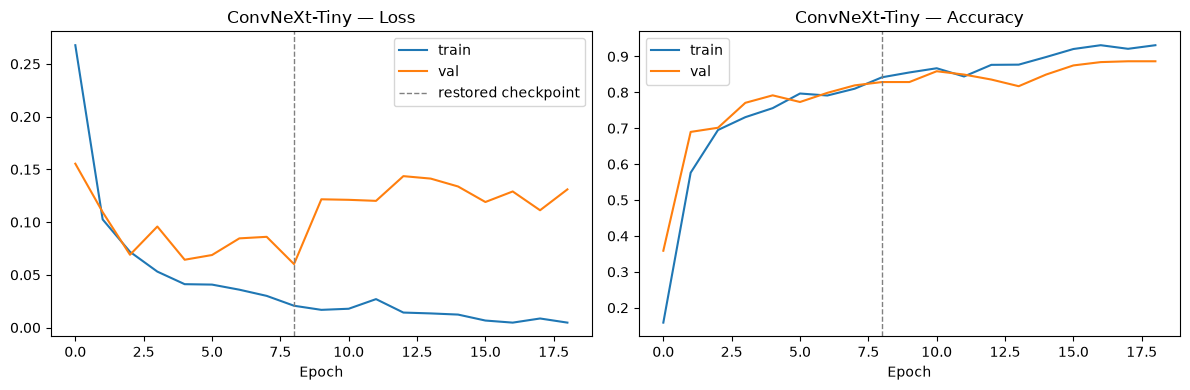

In [16]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.736


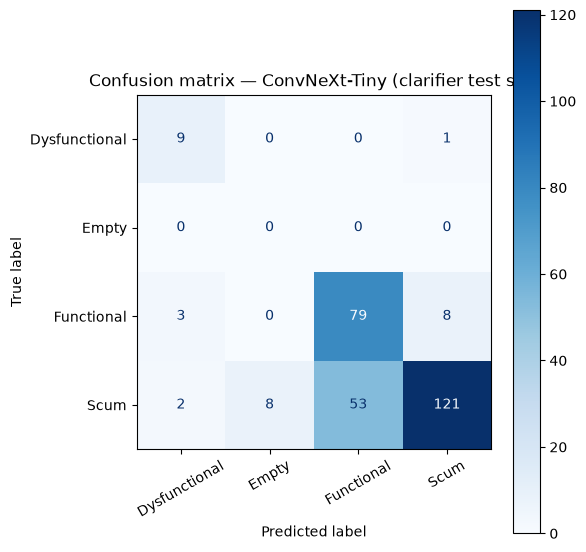

               precision    recall  f1-score   support

Dysfunctional      0.643     0.900     0.750        10
        Empty      0.000     0.000     0.000         0
   Functional      0.598     0.878     0.712        90
         Scum      0.931     0.658     0.771       184

     accuracy                          0.736       284
    macro avg      0.543     0.609     0.558       284
 weighted avg      0.815     0.736     0.751       284



/usr/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


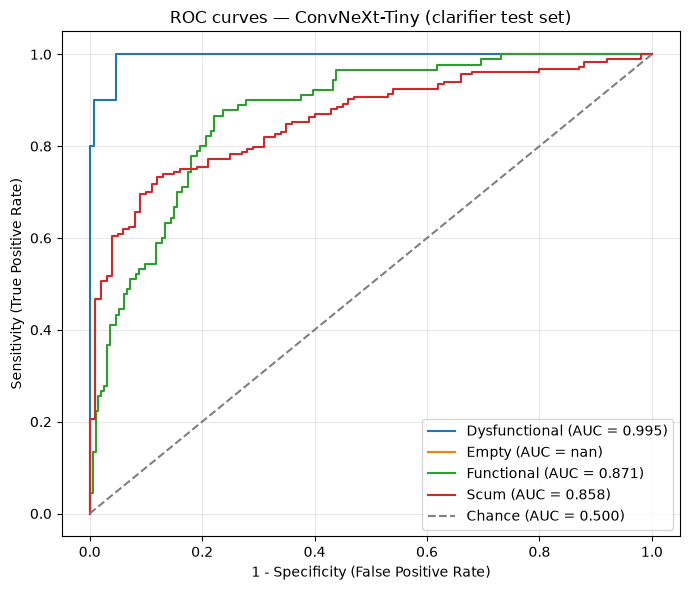

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.995
  Empty          : nan
  Functional     : 0.871
  Scum           : 0.858

Mean AUC: nan


(np.float64(0.7359154929577465),
 {'Dysfunctional': 0.9945255474452555,
  'Empty': nan,
  'Functional': 0.8713058419243985,
  'Scum': 0.8578804347826086})

In [17]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [18]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_Waterval.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
